In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error

In [3]:
af = pd.read_csv('https://raw.githubusercontent.com/raveendran2862/dataset/refs/heads/main/Churn_Modelling.csv')

In [5]:
af


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
af.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [23]:
af.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [7]:
af['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [8]:
af.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [9]:
af['Geography'] = af['Geography'].map({'France':0,'Germany':1,'Spain':2})

In [10]:
af['Gender'] = af['Gender'].map({'Female':0,'Male':1})

In [11]:
af.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  int64  
 5   Gender           10000 non-null  int64  
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(11), str(1)
memory usage: 1.1 MB


In [12]:
af.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [13]:
af.drop(['RowNumber','CustomerId','Surname'],axis = 1 , inplace = True)

In [72]:
x = af.drop(['Exited'], axis = 1)
y = af['Exited']

In [73]:
x

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0,1,1,1,101348
1,608,2,0,41,1,83807,1,0,1,112542
2,502,0,0,42,8,159660,3,1,0,113931
3,699,0,0,39,1,0,2,0,0,93826
4,850,2,0,43,2,125510,1,1,1,79084
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0,2,1,0,96270
9996,516,0,1,35,10,57369,1,1,1,101699
9997,709,0,0,36,7,0,1,0,1,42085
9998,772,1,1,42,3,75075,2,1,0,92888


In [59]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [58]:
af

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0,1,1,1,101348,1
1,608,2,0,41,1,83807,1,0,1,112542,0
2,502,0,0,42,8,159660,3,1,0,113931,1
3,699,0,0,39,1,0,2,0,0,93826,0
4,850,2,0,43,2,125510,1,1,1,79084,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0,2,1,0,96270,0
9996,516,0,1,35,10,57369,1,1,1,101699,0
9997,709,0,0,36,7,0,1,0,1,42085,1
9998,772,1,1,42,3,75075,2,1,0,92888,1


In [53]:
af.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


In [55]:
af["Balance"] = df["Balance"].astype(int)
af["EstimatedSalary"] = df["EstimatedSalary"].astype(int)


In [56]:
af.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CreditScore      10000 non-null  int64
 1   Geography        10000 non-null  int64
 2   Gender           10000 non-null  int64
 3   Age              10000 non-null  int64
 4   Tenure           10000 non-null  int64
 5   Balance          10000 non-null  int64
 6   NumOfProducts    10000 non-null  int64
 7   HasCrCard        10000 non-null  int64
 8   IsActiveMember   10000 non-null  int64
 9   EstimatedSalary  10000 non-null  int64
 10  Exited           10000 non-null  int64
dtypes: int64(11)
memory usage: 859.5 KB


In [74]:
lr = LogisticRegression()
lr.fit(x,y)

LogisticRegression()

In [75]:
y_pred = lr.predict(x)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [76]:
from sklearn.metrics import r2_score
r2_score(y,y_pred)

-0.28108456446608043

In [78]:

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y,y_pred)

0.7922

In [85]:
y.value_counts(normalize = True)

,proportion
Exited,
0,0.7963
1,0.2037


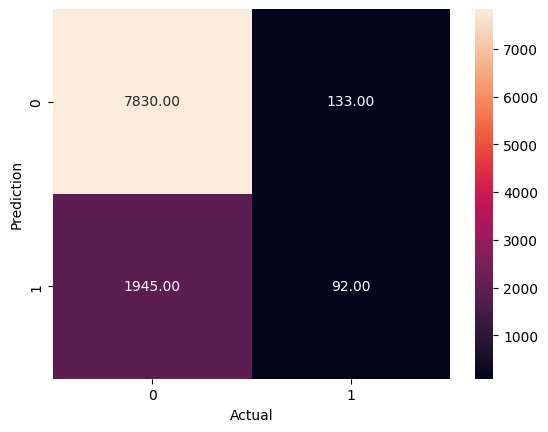

In [84]:
sns.heatmap(confusion_matrix(y,y_pred),annot = True,fmt = ".2f")
plt.xlabel("Actual")
plt.ylabel("Prediction");

In [87]:
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.98      0.88      7963
           1       0.41      0.05      0.08      2037

    accuracy                           0.79     10000
   macro avg       0.60      0.51      0.48     10000
weighted avg       0.72      0.79      0.72     10000

